# Notebook 5 — Comparative Statics

This notebook sweeps over key model parameters to understand how they affect:
- Bubble existence (leakage sum $\sum a_t$)
- The exorbitant privilege ($R_f - R^W_f$)
- Portfolio allocations and stock prices

**Parameters swept**:
1. $\chi$ (convenience yield) — controls the exorbitant privilege
2. $\kappa$ (home-bias cost) — controls portfolio distortion
3. $\pi$ (regime persistence) — controls expected bubble duration
4. $\gamma$ (risk aversion) — controls condition (2b)
5. $g_{D,u}$ (US dividend growth) — controls condition (2a)

In [2]:
using Pkg; Pkg.activate(".")
include("TwoCountryOLG.jl")
using Plots, LaTeXStrings, Printf
gr()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT`


Plots.GRBackend()

In [3]:
# ── Helper: run simulation and extract key statistics ──
function run_and_summarize(p::ModelParams)
    try
        res = run_simulation(p; verbose=false)
        s0 = res.u_path[1]
        d  = res.diagnostics

        # Full unbalanced-regime paths for path plots across parameter values
        ω_path = [s.ω for s in res.u_path]
        θ_path = [s.θ for s in res.u_path]
        θ_Us_path = [s.θ_US_star for s in res.u_path]
        ω_RoW_eq_path = [1.0 - s.ω_star for s in res.u_path]

        return (
            converged = true,
            ω_0       = s0.ω,
            ω_star_0  = s0.ω_star,
            θ_0       = s0.θ,
            θ_Us_0    = s0.θ_US_star,
            ω_path    = ω_path,
            θ_path    = θ_path,
            θ_Us_path = θ_Us_path,
            ω_RoW_eq_path = ω_RoW_eq_path,
            R_f_0     = s0.R_f,
            R_f_W_0   = s0.R_f_W,
            ep_0      = s0.R_f - s0.R_f_W,
            Q_US_0    = s0.Q_US,
            Q_W_0     = s0.Q_W,
            us_share  = s0.Q_US / (s0.Q_US + s0.Q_W),
            sum_at    = d.sum_a_t[end],
            sum_2a    = d.sum_dividend_ratio[end],
            sum_2b    = d.sum_cond_2b[end],
            bubble    = d.bubble_exists,
            result    = res
        )
    catch e
        @warn "Simulation failed" p e
        return (converged=false, ω_0=NaN, ω_star_0=NaN, θ_0=NaN, θ_Us_0=NaN,
                ω_path=Float64[], θ_path=Float64[], θ_Us_path=Float64[], ω_RoW_eq_path=Float64[],
                R_f_0=NaN, R_f_W_0=NaN, ep_0=NaN, Q_US_0=NaN, Q_W_0=NaN,
                us_share=NaN, sum_at=NaN, sum_2a=NaN, sum_2b=NaN,
                bubble=false, result=nothing)
    end
end;


## 1. Sweep over $\chi$ (Convenience Yield)

$\chi$ controls the RoW's demand for US bonds. Higher $\chi$ means:
- Stronger "exorbitant privilege" ($R_f - R^W_f$ larger)
- More US borrowing ($\theta$ more negative)
- Potentially affects bubble existence through the equity share channel

In [42]:
chi_vals = [0.005, 0.01, 0.02, 0.03]
chi_results = [run_and_summarize(ModelParams(χ=v)) for v in chi_vals]

println("\n══ χ Sweep Results ══")
println("   χ       R_f    R_f_W   EP      θ₀       Σaₜ      Bubble")
for (v, r) in zip(chi_vals, chi_results)
    r.converged || continue
    @printf("  %.3f   %.4f  %.4f  %+.4f  %+.6f  %.4f    %s\n",
            v, r.R_f_0, r.R_f_W_0, r.ep_0, r.θ_0, r.sum_at, r.bubble)
end

┌ Warning: solve_u_state_asymptote did not converge; falling back to balanced-state
└ @ Main /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT/TwoCountryOLG.jl:619
┌ Warning: solve_u_state_asymptote did not converge; falling back to balanced-state
└ @ Main /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT/TwoCountryOLG.jl:619
┌ Warning: Simulation failed
│   p = ModelParams
  β: Float64 0.5
  γ: Float64 0.5
  κ: Float64 0.01
  ω̄: Float64 0.8
  ω̄_star: Float64 0.2
  χ: Float64 0.02
  η: Float64 0.01
  π_persist: Float64 0.7
  g_e_u: Float64 1.1314082128906244
  g_e_b: Float64 1.0510100501000001
  g_D_u: Float64 1.0772840038843745
  g_D_W: Float64 1.0510100501000001
  g_e_W: Float64 1.0510100501000001
  e_US_0: Float64 1.0
  e_W_0: Float64 1.0
  D_e_ratio_0: Float64 0.04
  D_W_e_W_ratio_0: Float64 0.04
  λ_e: Float64 1.0
  λ_D: Float64 1.0
  ρ: Float64 0.9289397391015788
  ρ_D: Float64 0.975610931110424
  T_max: Int64 12


══ χ Sweep Results ══
   χ       R_f    R_f_W   EP      θ₀       Σaₜ      Bubble
  0.005   1.1410  1.1531  -0.0121  -0.945447  50.3306    true
  0.010   1.1337  1.1529  -0.0192  -1.186951  50.8830    true
  0.030   1.1147  1.1520  -0.0373  -1.799174  17.2268    true


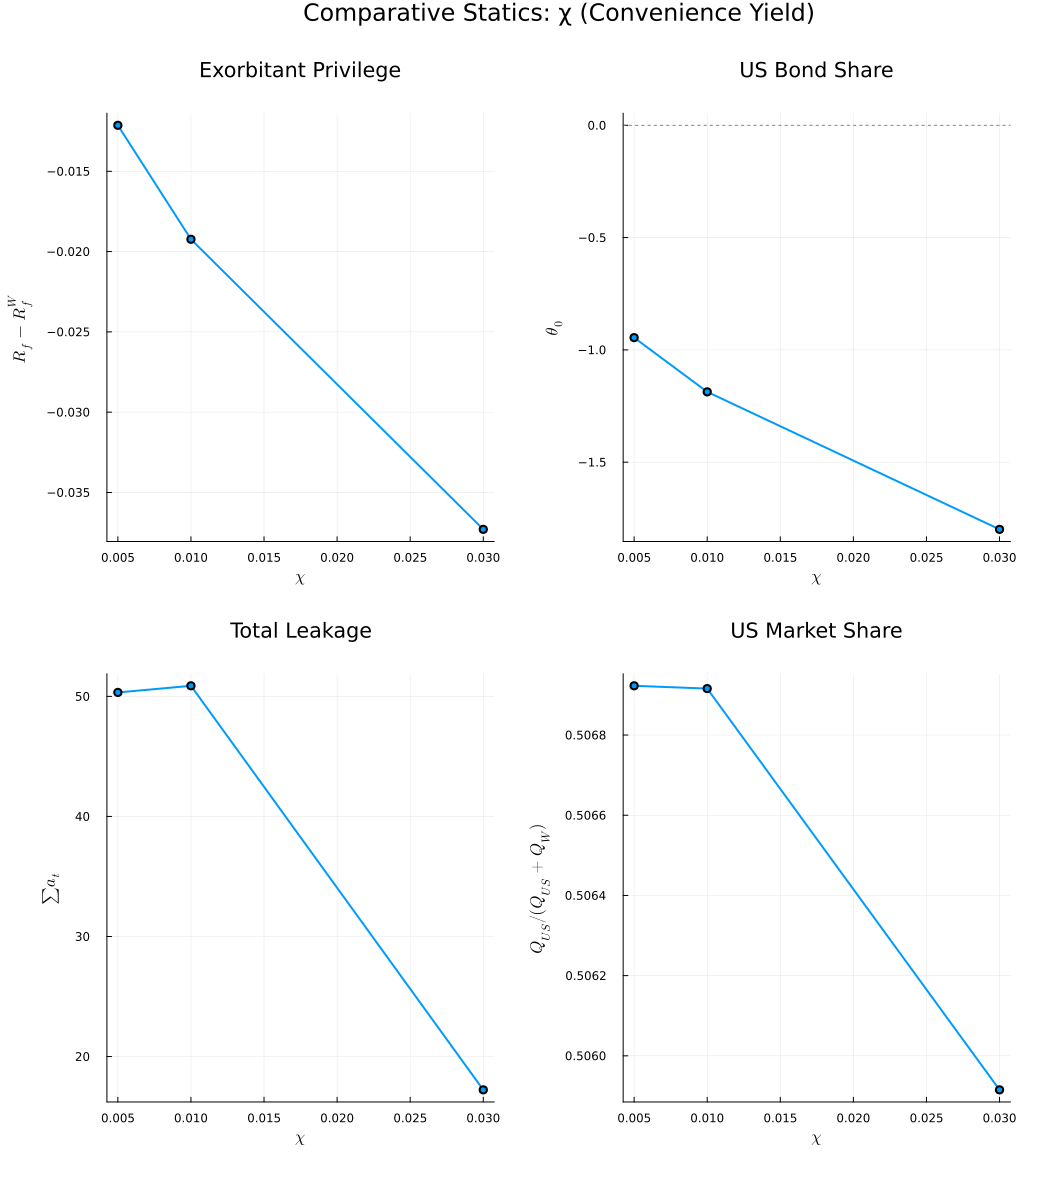

In [43]:
mask = [r.converged for r in chi_results]
xv = chi_vals[mask]

cp1 = plot(xv, [r.ep_0 for r in chi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\chi", ylabel=L"R_f - R^W_f",
           title="Exorbitant Privilege", legend=false)

cp2 = plot(xv, [r.θ_0 for r in chi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\chi", ylabel=L"\theta_0",
           title="US Bond Share", legend=false)
hline!(cp2, [0.0], ls=:dot, lc=:gray)

cp3 = plot(xv, [r.sum_at for r in chi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\chi", ylabel=L"\sum a_t",
           title="Total Leakage", legend=false)

cp4 = plot(xv, [r.us_share for r in chi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\chi", ylabel=L"Q_{US}/(Q_{US}+Q_W)",
           title="US Market Share", legend=false)

plot(cp1, cp2, cp3, cp4, layout=(2,2), size=(1040, 1180), margin=5Plots.mm,
     plot_title="Comparative Statics: χ (Convenience Yield)")

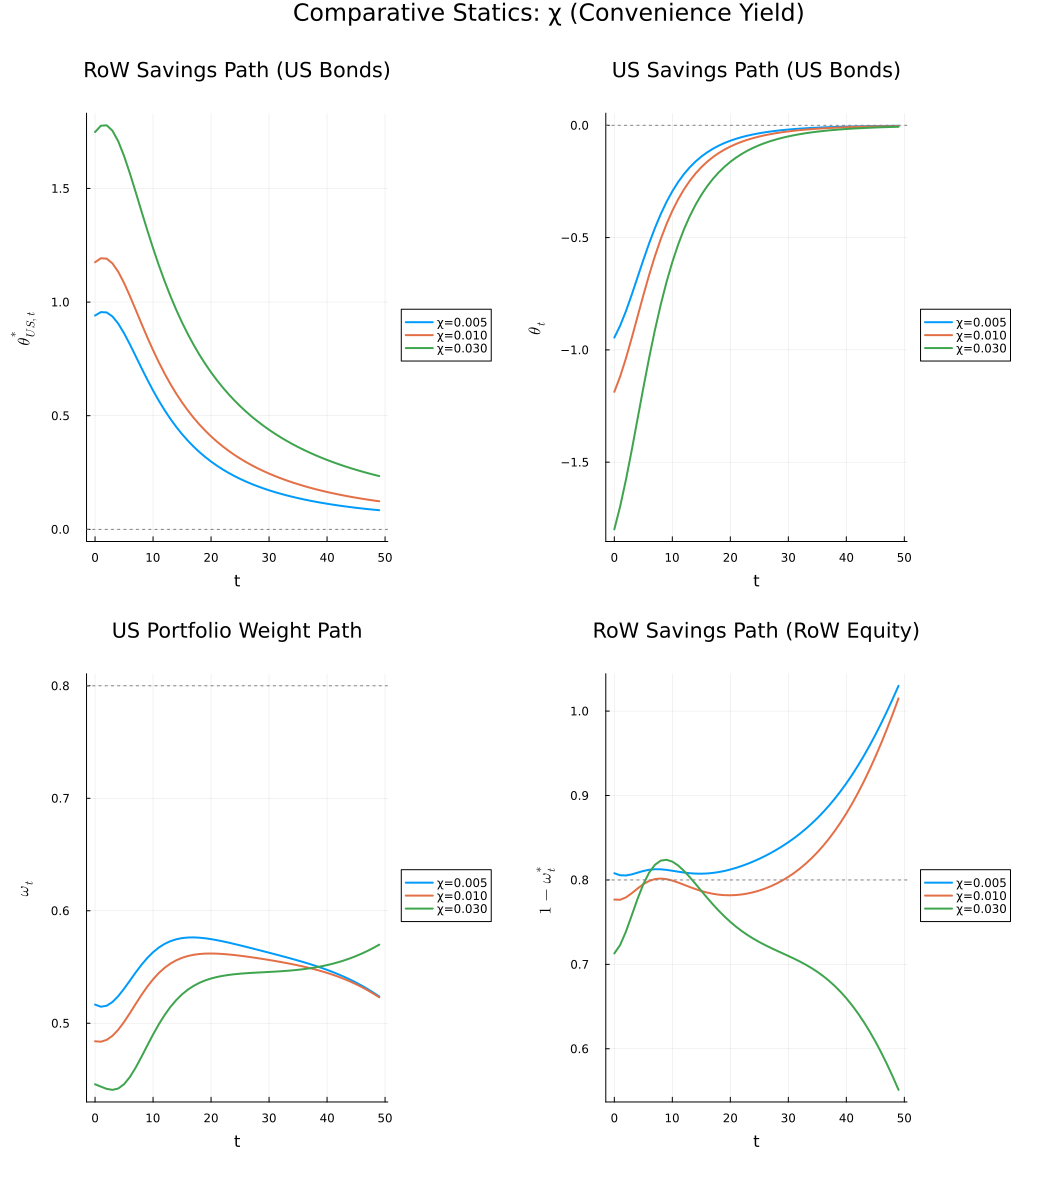

In [44]:
plot_periods = 50

# Backward-compatible path recovery in case chi_results was computed
# before the helper tuple included all cached path fields.
θ_path_of(r) = hasproperty(r, :θ_path) ? r.θ_path : [s.θ for s in r.result.u_path]

cp5 = plot(xlabel="t", ylabel=L"\theta^{*}_{US,t}",
           title="RoW Savings Path (US Bonds)", legend=:outerright)
for (v, r) in zip(chi_vals[mask], chi_results[mask])
    n_plot = min(plot_periods, length(r.θ_Us_path))
    t = 0:(n_plot-1)
    plot!(cp5, t, r.θ_Us_path[1:n_plot], lw=2, label=@sprintf("χ=%.3f", v))
end
hline!(cp5, [0.0], ls=:dot, lc=:gray, label="")

cp6 = plot(xlabel="t", ylabel=L"\theta_t",
           title="US Savings Path (US Bonds)", legend=:outerright)
for (v, r) in zip(chi_vals[mask], chi_results[mask])
    θ_path = θ_path_of(r)
    n_plot = min(plot_periods, length(θ_path))
    t = 0:(n_plot-1)
    plot!(cp6, t, θ_path[1:n_plot], lw=2, label=@sprintf("χ=%.3f", v))
end
hline!(cp6, [0.0], ls=:dot, lc=:gray, label="")

cp7 = plot(xlabel="t", ylabel=L"\omega_t",
           title="US Portfolio Weight Path", legend=:outerright)
for (v, r) in zip(chi_vals[mask], chi_results[mask])
    n_plot = min(plot_periods, length(r.ω_path))
    t = 0:(n_plot-1)
    plot!(cp7, t, r.ω_path[1:n_plot], lw=2, label=@sprintf("χ=%.3f", v))
end
hline!(cp7, [0.80], ls=:dot, lc=:gray, label="")

cp8 = plot(xlabel="t", ylabel=L"1-\omega^*_t",
           title="RoW Savings Path (RoW Equity)", legend=:outerright)
for (v, r) in zip(chi_vals[mask], chi_results[mask])
    n_plot = min(plot_periods, length(r.ω_RoW_eq_path))
    t = 0:(n_plot-1)
    plot!(cp8, t, r.ω_RoW_eq_path[1:n_plot], lw=2, label=@sprintf("χ=%.3f", v))
end
hline!(cp8, [0.80], ls=:dot, lc=:gray, label="")

plot(cp5, cp6, cp7, cp8, layout=(2,2), size=(1040, 1180), margin=5Plots.mm,
     plot_title="Comparative Statics: χ (Convenience Yield)")

## 2. Sweep over $\kappa$ (Home-Bias Cost)

$\kappa$ penalises deviations from the home-bias target. Higher $\kappa$:
- Keeps portfolio weights closer to targets ($\bar\omega$, $\bar\omega^*$)
- Increases the effective return wedge between US and RoW equities
- Must satisfy Lemma 1: $\kappa < \beta/\bar\omega$

In [57]:
kappa_max = 0.5 * 0.625  # well below beta/omega_bar = 0.625
kappa_vals = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]
kappa_results = [run_and_summarize(ModelParams(κ=v)) for v in kappa_vals]

println("\n══ κ Sweep Results ══")
println("   κ       ω₀     ω*₀    R_f     Σaₜ      Bubble")
for (v, r) in zip(kappa_vals, kappa_results)
    r.converged || continue
    @printf("  %.3f   %.4f  %.4f  %.4f  %.4f    %s\n",
            v, r.ω_0, r.ω_star_0, r.R_f_0, r.sum_at, r.bubble)
end

┌ Warning: solve_u_state_asymptote did not converge; falling back to balanced-state
└ @ Main /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT/TwoCountryOLG.jl:619
┌ Warning: Simulation failed
│   p = ModelParams
  β: Float64 0.5
  γ: Float64 0.5
  κ: Float64 0.001
  ω̄: Float64 0.8
  ω̄_star: Float64 0.2
  χ: Float64 0.01
  η: Float64 0.01
  π_persist: Float64 0.7
  g_e_u: Float64 1.1314082128906244
  g_e_b: Float64 1.0510100501000001
  g_D_u: Float64 1.0772840038843745
  g_D_W: Float64 1.0510100501000001
  g_e_W: Float64 1.0510100501000001
  e_US_0: Float64 1.0
  e_W_0: Float64 1.0
  D_e_ratio_0: Float64 0.04
  D_W_e_W_ratio_0: Float64 0.04
  λ_e: Float64 1.0
  λ_D: Float64 1.0
  ρ: Float64 0.9289397391015788
  ρ_D: Float64 0.975610931110424
  T_max: Int64 120
  ftol: Float64 1.0e-12
  xtol: Float64 1.0e-12
  iterations: Int64 5000

│   e = DomainError(-0.24424448891817943, "Exponentiation yielding a complex result requires a complex argument.\nReplac


══ κ Sweep Results ══
   κ       ω₀     ω*₀    R_f     Σaₜ      Bubble
  0.010   0.4840  0.2232  1.1337  50.8830    true
  0.020   0.4948  0.2214  1.1343  16.5537    true
  0.050   0.5257  0.2126  1.1362  16.3360    true
  0.100   0.5721  0.2001  1.1388  16.1007    true


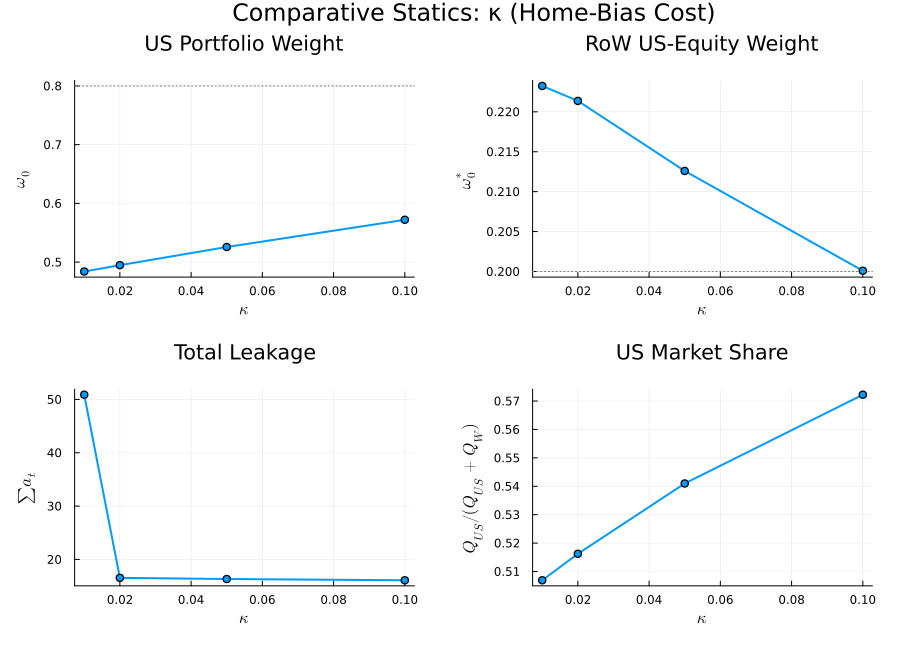

In [58]:
mask = [r.converged for r in kappa_results]
xv = kappa_vals[mask]

kp1 = plot(xv, [r.ω_0 for r in kappa_results[mask]], lw=2, marker=:circle,
           xlabel=L"\kappa", ylabel=L"\omega_0",
           title="US Portfolio Weight", legend=false)
hline!(kp1, [0.80], ls=:dot, lc=:gray)

kp2 = plot(xv, [r.ω_star_0 for r in kappa_results[mask]], lw=2, marker=:circle,
           xlabel=L"\kappa", ylabel=L"\omega^*_0",
           title="RoW US-Equity Weight", legend=false)
hline!(kp2, [0.20], ls=:dot, lc=:gray)

kp3 = plot(xv, [r.sum_at for r in kappa_results[mask]], lw=2, marker=:circle,
           xlabel=L"\kappa", ylabel=L"\sum a_t",
           title="Total Leakage", legend=false)

kp4 = plot(xv, [r.us_share for r in kappa_results[mask]], lw=2, marker=:circle,
           xlabel=L"\kappa", ylabel=L"Q_{US}/(Q_{US}+Q_W)",
           title="US Market Share", legend=false)

plot(kp1, kp2, kp3, kp4, layout=(2,2), size=(900, 650), margin=5Plots.mm,
     plot_title="Comparative Statics: κ (Home-Bias Cost)")

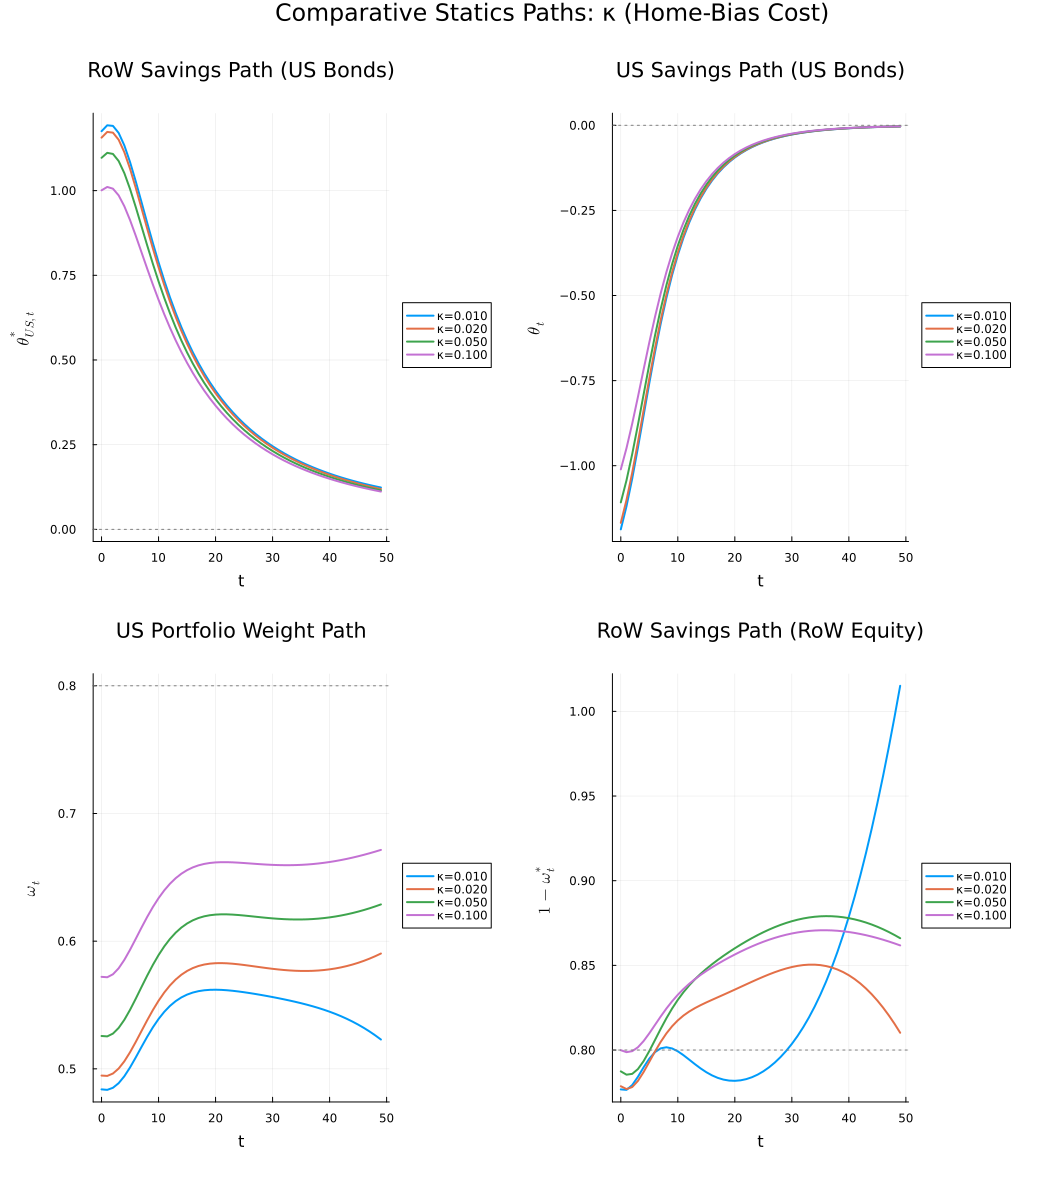

In [59]:
plot_periods = 50

# Backward-compatible path recovery in case kappa_results was computed
# before the helper tuple included all cached path fields.
θ_path_of(r) = hasproperty(r, :θ_path) ? r.θ_path : [s.θ for s in r.result.u_path]

kp5 = plot(xlabel="t", ylabel=L"\theta^{*}_{US,t}",
           title="RoW Savings Path (US Bonds)", legend=:outerright)
for (v, r) in zip(kappa_vals[mask], kappa_results[mask])
    n_plot = min(plot_periods, length(r.θ_Us_path))
    t = 0:(n_plot-1)
    plot!(kp5, t, r.θ_Us_path[1:n_plot], lw=2, label=@sprintf("κ=%.3f", v))
end
hline!(kp5, [0.0], ls=:dot, lc=:gray, label="")

kp6 = plot(xlabel="t", ylabel=L"\theta_t",
           title="US Savings Path (US Bonds)", legend=:outerright)
for (v, r) in zip(kappa_vals[mask], kappa_results[mask])
    θ_path = θ_path_of(r)
    n_plot = min(plot_periods, length(θ_path))
    t = 0:(n_plot-1)
    plot!(kp6, t, θ_path[1:n_plot], lw=2, label=@sprintf("κ=%.3f", v))
end
hline!(kp6, [0.0], ls=:dot, lc=:gray, label="")

kp7 = plot(xlabel="t", ylabel=L"\omega_t",
           title="US Portfolio Weight Path", legend=:outerright)
for (v, r) in zip(kappa_vals[mask], kappa_results[mask])
    n_plot = min(plot_periods, length(r.ω_path))
    t = 0:(n_plot-1)
    plot!(kp7, t, r.ω_path[1:n_plot], lw=2, label=@sprintf("κ=%.3f", v))
end
hline!(kp7, [0.80], ls=:dot, lc=:gray, label="")

kp8 = plot(xlabel="t", ylabel=L"1-\omega^*_t",
           title="RoW Savings Path (RoW Equity)", legend=:outerright)
for (v, r) in zip(kappa_vals[mask], kappa_results[mask])
    n_plot = min(plot_periods, length(r.ω_RoW_eq_path))
    t = 0:(n_plot-1)
    plot!(kp8, t, r.ω_RoW_eq_path[1:n_plot], lw=2, label=@sprintf("κ=%.3f", v))
end
hline!(kp8, [0.80], ls=:dot, lc=:gray, label="")

plot(kp5, kp6, kp7, kp8, layout=(2,2), size=(1040, 1180), margin=5Plots.mm,
     plot_title="Comparative Statics Paths: κ (Home-Bias Cost)")

## 3. Sweep over $e_{W,0}$ (Relative RoW Size)

$e_{W,0}$ is the initial endowment size of the Rest of the World. Since $e_{US,0}=1$, varying $e_{W,0}$ changes the relative size of the RoW economy to the US.

We trace how relative RoW size affects the transition paths of:
- RoW savings in US bonds, $\theta^{*}_{US,t}$
- US savings in US bonds, $\theta_t$
- US portfolio weight, $\omega_t$
- RoW savings in RoW equity, $1-\omega_t^*$


In [4]:
eW_vals = [1.0, 3.0, 6.0, 9.0]
eW_results = [run_and_summarize(ModelParams(e_W_0=v)) for v in eW_vals]

println("\nRelative RoW size sweep:")
for (v, r) in zip(eW_vals, eW_results)
    println(@sprintf("e_W_0 = %.1f | converged=%s | bubble=%s | θ_US*0=%.3f | θ0=%.3f | ω0=%.3f",
                     v, r.converged, r.bubble, r.θ_Us_0, r.θ_0, r.ω_0))
end


┌ Warning: solve_u_state_asymptote did not converge; falling back to balanced-state
└ @ Main ~/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT/TwoCountryOLG.jl:619
┌ Warning: solve_u_state_asymptote did not converge; falling back to balanced-state
└ @ Main ~/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT/TwoCountryOLG.jl:619
┌ Warning: solve_u_state_asymptote did not converge; falling back to balanced-state
└ @ Main ~/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT/TwoCountryOLG.jl:619
┌ Warning: solve_u_state_asymptote did not converge; falling back to balanced-state
└ @ Main ~/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT/TwoCountryOLG.jl:619



Relative RoW size sweep:
e_W_0 = 1.0 | converged=true | bubble=true | θ_US*0=0.941 | θ0=-0.945 | ω0=0.517
e_W_0 = 3.0 | converged=true | bubble=false | θ_US*0=0.464 | θ0=-1.398 | ω0=0.362
e_W_0 = 6.0 | converged=true | bubble=false | θ_US*0=0.306 | θ0=-1.842 | ω0=0.270
e_W_0 = 9.0 | converged=true | bubble=false | θ_US*0=0.240 | θ0=-2.175 | ω0=0.219


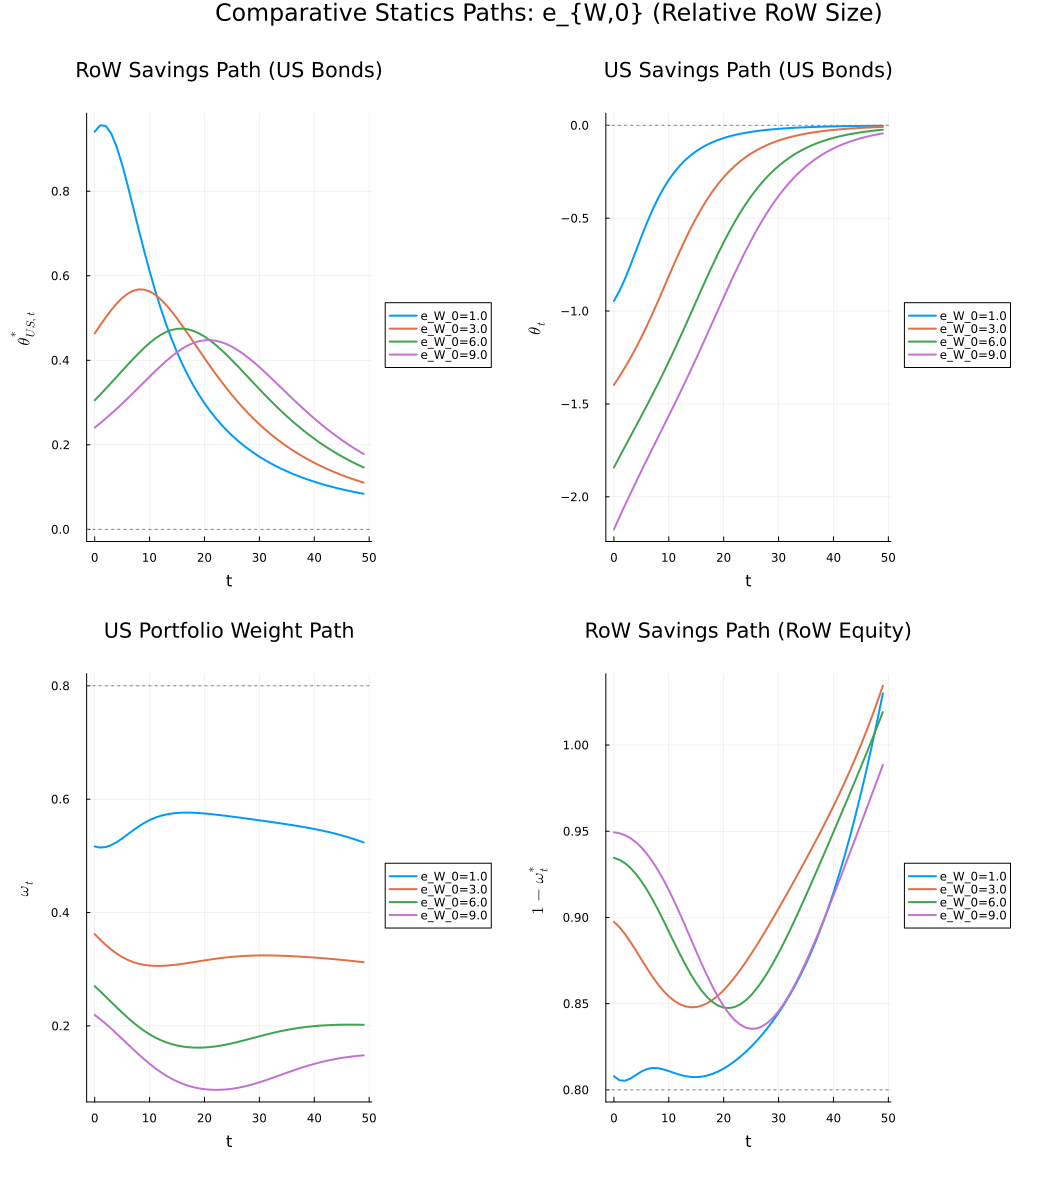

In [8]:
plot_periods = 50

# Backward-compatible path recovery in case eW_results was computed
# before the helper tuple included all cached path fields.
θ_path_of(r) = hasproperty(r, :θ_path) ? r.θ_path : [s.θ for s in r.result.u_path]

mask = [r.converged for r in eW_results]

ewp5 = plot(xlabel="t", ylabel=L"\theta^{*}_{US,t}",
            title="RoW Savings Path (US Bonds)", legend=:outerright)
for (v, r) in zip(eW_vals[mask], eW_results[mask])
    n_plot = min(plot_periods, length(r.θ_Us_path))
    t = 0:(n_plot-1)
    plot!(ewp5, t, r.θ_Us_path[1:n_plot], lw=2, label=@sprintf("e_W_0=%.1f", v))
end
hline!(ewp5, [0.0], ls=:dot, lc=:gray, label="")

ewp6 = plot(xlabel="t", ylabel=L"\theta_t",
            title="US Savings Path (US Bonds)", legend=:outerright)
for (v, r) in zip(eW_vals[mask], eW_results[mask])
    θ_path = θ_path_of(r)
    n_plot = min(plot_periods, length(θ_path))
    t = 0:(n_plot-1)
    plot!(ewp6, t, θ_path[1:n_plot], lw=2, label=@sprintf("e_W_0=%.1f", v))
end
hline!(ewp6, [0.0], ls=:dot, lc=:gray, label="")

ewp7 = plot(xlabel="t", ylabel=L"\omega_t",
            title="US Portfolio Weight Path", legend=:outerright)
for (v, r) in zip(eW_vals[mask], eW_results[mask])
    n_plot = min(plot_periods, length(r.ω_path))
    t = 0:(n_plot-1)
    plot!(ewp7, t, r.ω_path[1:n_plot], lw=2, label=@sprintf("e_W_0=%.1f", v))
end
hline!(ewp7, [0.80], ls=:dot, lc=:gray, label="")

ewp8 = plot(xlabel="t", ylabel=L"1-\omega^*_t",
            title="RoW Savings Path (RoW Equity)", legend=:outerright)
for (v, r) in zip(eW_vals[mask], eW_results[mask])
    n_plot = min(plot_periods, length(r.ω_RoW_eq_path))
    t = 0:(n_plot-1)
    plot!(ewp8, t, r.ω_RoW_eq_path[1:n_plot], lw=2, label=@sprintf("e_W_0=%.1f", v))
end
hline!(ewp8, [0.80], ls=:dot, lc=:gray, label="")

plot(ewp5, ewp6, ewp7, ewp8, layout=(2,2), size=(1040, 1180), margin=5Plots.mm,
     plot_title="Comparative Statics Paths: e_{W,0} (Relative RoW Size)")


## 4. Sweep over $\pi$ (Regime Persistence)

$\pi$ is the probability of staying in unbalanced growth. Higher $\pi$:
- Longer expected bubble duration ($E[\tau] = 1/(1-\pi)$)
- Makes the switch leakage term smaller (less probability mass on switching)
- Should make bubbles more likely to exist

In [7]:
pi_vals = [0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
pi_results = [run_and_summarize(ModelParams(π_persist=v)) for v in pi_vals]

println("\n══ π Sweep Results ══")
println("   π     E[τ]   R_f     EP      Σaₜ       Bubble")
for (v, r) in zip(pi_vals, pi_results)
    r.converged || continue
    @printf("  %.2f   %5.1f  %.4f  %+.4f  %8.4f    %s\n",
            v, 1/(1-v), r.R_f_0, r.ep_0, r.sum_at, r.bubble)
end

┌ Warning: solve_u_state_asymptote did not converge; falling back to balanced-state
└ @ Main /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT/TwoCountryOLG.jl:611
┌ Warning: solve_u_state_asymptote did not converge; falling back to balanced-state
└ @ Main /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT/TwoCountryOLG.jl:611



══ π Sweep Results ══
   π     E[τ]   R_f     EP      Σaₜ       Bubble
  0.40     1.7  1.0616  -0.0694  343.8569    false
  0.50     2.0  1.0651  -0.0696   48.3421    false
  0.60     2.5  1.0687  -0.0698  157.5410    false
  0.70     3.3  1.0723  -0.0701   21.8105    false
  0.80     5.0  1.0759  -0.0703   13.5432    false
  0.90    10.0  1.0795  -0.0704    7.1294    false
  0.95    20.0  1.0813  -0.0706    4.4100    false


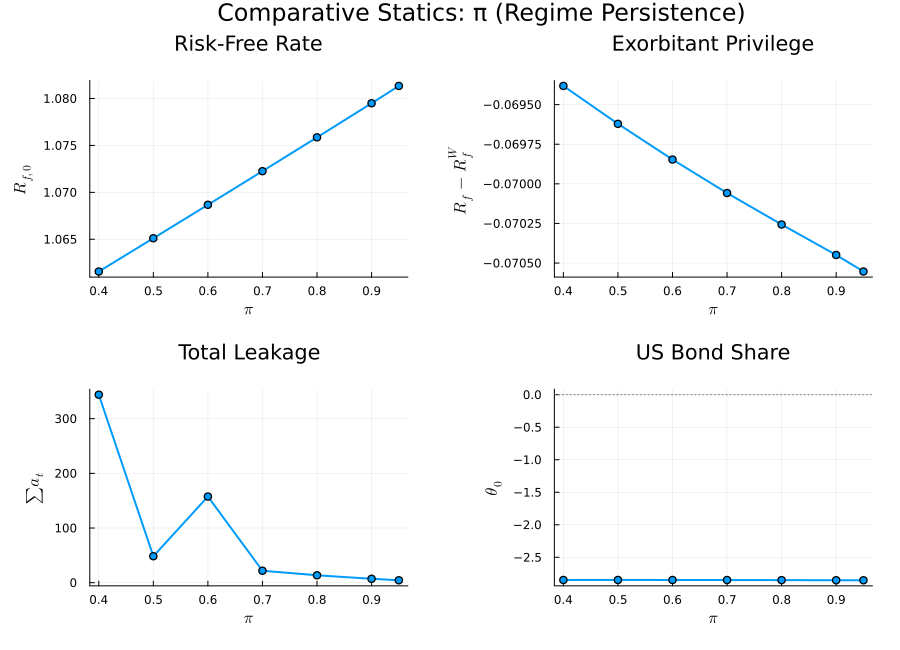

In [8]:
mask = [r.converged for r in pi_results]
xv = pi_vals[mask]

pp1 = plot(xv, [r.R_f_0 for r in pi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\pi", ylabel=L"R_{f,0}",
           title="Risk-Free Rate", legend=false)

pp2 = plot(xv, [r.ep_0 for r in pi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\pi", ylabel=L"R_f - R^W_f",
           title="Exorbitant Privilege", legend=false)

pp3 = plot(xv, [r.sum_at for r in pi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\pi", ylabel=L"\sum a_t",
           title="Total Leakage", legend=false)

pp4 = plot(xv, [r.θ_0 for r in pi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\pi", ylabel=L"\theta_0",
           title="US Bond Share", legend=false)
hline!(pp4, [0.0], ls=:dot, lc=:gray)

plot(pp1, pp2, pp3, pp4, layout=(2,2), size=(900, 650), margin=5Plots.mm,
     plot_title="Comparative Statics: π (Regime Persistence)")

## 5. Sweep over $\gamma$ (Risk Aversion)

$\gamma$ controls condition (2b): $\sum (C^b/C^u)^{1-\gamma}$.
- For $\gamma > 1$ and $C^u > C^b$: the term $(C^b/C^u)^{1-\gamma} = (C^b/C^u)^{-(\gamma-1)}$ is large, making convergence harder.
- For $\gamma > 1$ and $C^u < C^b$: the term is small and convergence is easy.
- Higher $\gamma$ also affects portfolio allocations and the equity premium.

In [9]:
gamma_vals = [1.5, 2.0, 3.0, 4.0, 5.0]
gamma_results = [run_and_summarize(ModelParams(γ=v)) for v in gamma_vals]

println("\n══ γ Sweep Results ══")
println("   γ     R_f     EP       Σ(2b)     Σaₜ      Bubble")
for (v, r) in zip(gamma_vals, gamma_results)
    r.converged || continue
    @printf("  %.1f   %.4f  %+.4f  %8.4f  %8.4f    %s\n",
            v, r.R_f_0, r.ep_0, r.sum_2b, r.sum_at, r.bubble)
end

┌ Warning: solve_u_state_asymptote did not converge; falling back to balanced-state
└ @ Main /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT/TwoCountryOLG.jl:611
┌ Warning: solve_u_state_asymptote did not converge; falling back to balanced-state
└ @ Main /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT/TwoCountryOLG.jl:611
┌ Warning: solve_u_state_asymptote did not converge; falling back to balanced-state
└ @ Main /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT/TwoCountryOLG.jl:611



══ γ Sweep Results ══
   γ     R_f     EP       Σ(2b)     Σaₜ      Bubble
  1.5   1.0718  -0.0703  990.8382  121219478071532479745116934959529984.0000    false
  2.0   1.0716  -0.0705  16991.6550  9826573654734198013952.0000    false
  3.0   1.0712  -0.0708  9878020.7089  3202458766.6262    false
  4.0   1.0708  -0.0711  7641140259.5785  3584368780021.7637    false
  5.0   1.0704  -0.0715  6638254326522.8125  4012520602142643.0000    false


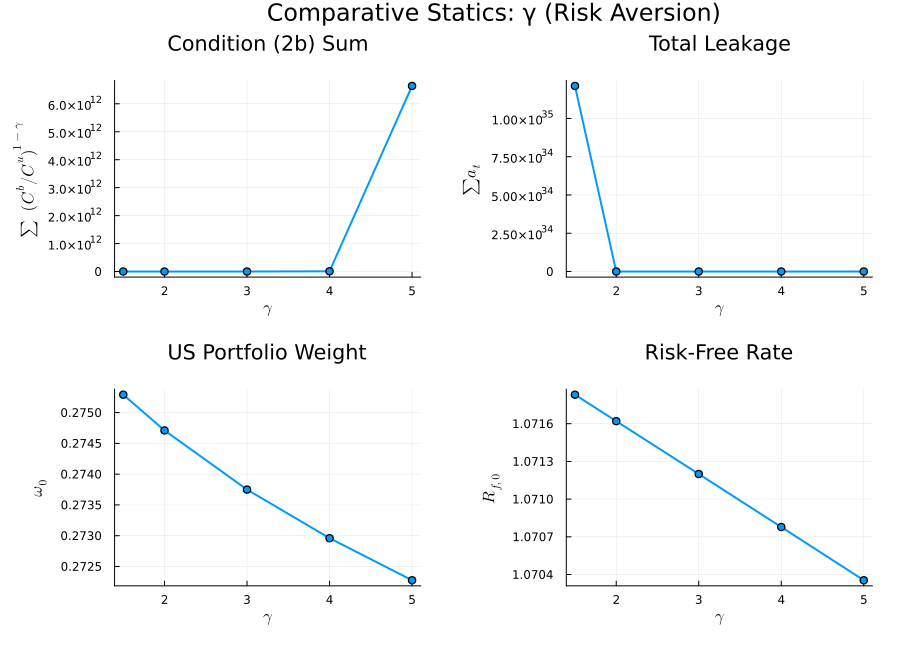

In [10]:
mask = [r.converged for r in gamma_results]
xv = gamma_vals[mask]

gp1 = plot(xv, [r.sum_2b for r in gamma_results[mask]], lw=2, marker=:circle,
           xlabel=L"\gamma", ylabel=L"\sum (C^b/C^u)^{1-\gamma}",
           title="Condition (2b) Sum", legend=false)

gp2 = plot(xv, [r.sum_at for r in gamma_results[mask]], lw=2, marker=:circle,
           xlabel=L"\gamma", ylabel=L"\sum a_t",
           title="Total Leakage", legend=false)

gp3 = plot(xv, [r.ω_0 for r in gamma_results[mask]], lw=2, marker=:circle,
           xlabel=L"\gamma", ylabel=L"\omega_0",
           title="US Portfolio Weight", legend=false)

gp4 = plot(xv, [r.R_f_0 for r in gamma_results[mask]], lw=2, marker=:circle,
           xlabel=L"\gamma", ylabel=L"R_{f,0}",
           title="Risk-Free Rate", legend=false)

plot(gp1, gp2, gp3, gp4, layout=(2,2), size=(900, 650), margin=5Plots.mm,
     plot_title="Comparative Statics: γ (Risk Aversion)")

## 6. Sweep over $g_{D,u}$ (US Dividend Growth)

The gap between $g_{D,u}$ and $g_{e,u}$ is the primary driver of condition (2a).
- When $g_{D,u} \to g_{e,u}$: $D/e$ stays constant, sum diverges, no bubble.
- When $g_{D,u} \ll g_{e,u}$: $D/e \to 0$ quickly, strong bubble conditions.

In [11]:
# Annual growth rates for dividends
gD_annual = [0.005, 0.010, 0.012, 0.015, 0.020, 0.025, 0.030]
gD_vals = [(1.0 + g)^5 for g in gD_annual]   # per-period (5 years)

gD_results = [run_and_summarize(ModelParams(g_D_u=v)) for v in gD_vals]

println("\n══ g_D Sweep Results ══")
println("  g_D(ann)  g_D(5yr)  g_D/g_e   Σ(2a)      Σaₜ       Bubble")
for (ga, v, r) in zip(gD_annual, gD_vals, gD_results)
    r.converged || continue
    @printf("  %.3f    %.4f   %.4f   %9.4f  %9.4f    %s\n",
            ga, v, v / ModelParams().g_e_u, r.sum_2a, r.sum_at, r.bubble)
end


══ g_D Sweep Results ══
  g_D(ann)  g_D(5yr)  g_D/g_e   Σ(2a)      Σaₜ       Bubble
  0.005    1.0253   0.9062      0.3863    20.6743    false
  0.010    1.0510   0.9289      0.5228    20.9729    false
  0.012    1.0615   0.9382      0.6067    21.2282    false
  0.015    1.0773   0.9522      0.7938    21.8105    false
  0.020    1.1041   0.9758      1.5280    24.4735    false
  0.025    1.1314   1.0000      4.7600    36.1406    false
  0.030    1.1593   1.0246     28.4398   107.2619    false


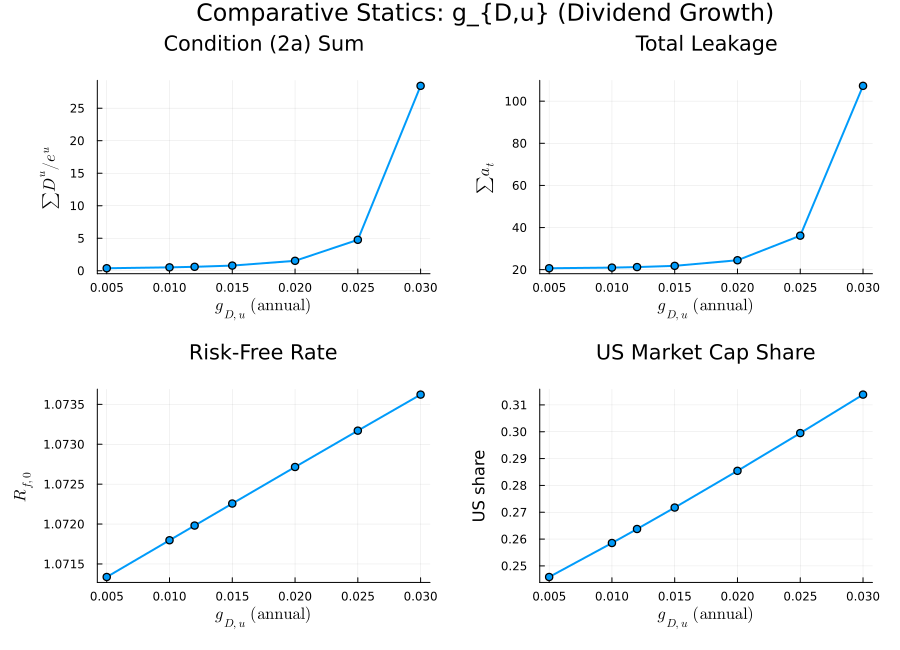

In [12]:
mask = [r.converged for r in gD_results]
xv = gD_annual[mask]

gdp1 = plot(xv, [r.sum_2a for r in gD_results[mask]], lw=2, marker=:circle,
            xlabel=L"g_{D,u}\ (\mathrm{annual})", ylabel=L"\sum D^u/e^u",
            title="Condition (2a) Sum", legend=false)

gdp2 = plot(xv, [r.sum_at for r in gD_results[mask]], lw=2, marker=:circle,
            xlabel=L"g_{D,u}\ (\mathrm{annual})", ylabel=L"\sum a_t",
            title="Total Leakage", legend=false)

# Bubble share at t=1 (if available)
bshare = Float64[]
for r in gD_results[mask]
    if r.result !== nothing
        push!(bshare, r.Q_US_0)  # placeholder; actual share needs V computation
    else
        push!(bshare, NaN)
    end
end

gdp3 = plot(xv, [r.R_f_0 for r in gD_results[mask]], lw=2, marker=:circle,
            xlabel=L"g_{D,u}\ (\mathrm{annual})", ylabel=L"R_{f,0}",
            title="Risk-Free Rate", legend=false)

gdp4 = plot(xv, [r.us_share for r in gD_results[mask]], lw=2, marker=:circle,
            xlabel=L"g_{D,u}\ (\mathrm{annual})", ylabel="US share",
            title="US Market Cap Share", legend=false)

plot(gdp1, gdp2, gdp3, gdp4, layout=(2,2), size=(900, 650), margin=5Plots.mm,
     plot_title="Comparative Statics: g_{D,u} (Dividend Growth)")

## 7. Summary Table

Collecting the key finding from each sweep.

In [13]:
println("\n══════════════════════════════════════════════════════")
println("        COMPARATIVE STATICS SUMMARY")
println("══════════════════════════════════════════════════════")
println()
println("χ (convenience yield):")
println("  ↑ χ  ⟹  ↑ exorbitant privilege, ↑ US borrowing")
println()
println("κ (home-bias cost):")
println("  ↑ κ  ⟹  portfolio closer to targets, affects return wedge")
println()
println("π (regime persistence):")
println("  ↑ π  ⟹  longer bubble episodes, affects leakage via switch probability")
println()
println("γ (risk aversion):")
println("  ↑ γ  ⟹  affects condition (2b) summability and equity premium")
println()
println("g_D,u (dividend growth):")
println("  ↓ g_D  ⟹  faster D/e decay, easier bubble formation (cond 2a)")
println("  g_D → g_e ⟹  no bubble (cond 2a fails)")


══════════════════════════════════════════════════════
        COMPARATIVE STATICS SUMMARY
══════════════════════════════════════════════════════

χ (convenience yield):
  ↑ χ  ⟹  ↑ exorbitant privilege, ↑ US borrowing

κ (home-bias cost):
  ↑ κ  ⟹  portfolio closer to targets, affects return wedge

π (regime persistence):
  ↑ π  ⟹  longer bubble episodes, affects leakage via switch probability

γ (risk aversion):
  ↑ γ  ⟹  affects condition (2b) summability and equity premium

g_D,u (dividend growth):
  ↓ g_D  ⟹  faster D/e decay, easier bubble formation (cond 2a)
  g_D → g_e ⟹  no bubble (cond 2a fails)


## Summary

The comparative statics confirm the model's key mechanisms:

1. **Convenience yield $\chi$**: Directly controls the exorbitant privilege and US net borrowing. Higher $\chi$ strengthens the US's ability to borrow cheaply, which can amplify bubble dynamics.

2. **Home-bias cost $\kappa$**: Keeps portfolios near their targets. Small $\kappa$ allows more portfolio adjustment, potentially affecting the effective pricing kernel.

3. **Regime persistence $\pi$**: Higher $\pi$ means longer expected unbalanced growth episodes. This directly affects the leakage ratio through the $(1-\pi)/\pi$ factor in the switch term.

4. **Risk aversion $\gamma$**: Affects condition (2b) through the power $(1-\gamma)$. With $\gamma > 1$, the consumption ratio term can grow or shrink depending on whether the switch improves or worsens consumption.

5. **Dividend growth gap**: The most direct lever for bubble existence. When $g_{D,u} \approx g_{e,u}$, condition (2a) fails and no bubble can exist.